In [ ]:
import sys, os
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
os.chdir(r'C:\\ARMA')
from colorsetup import colors, palette
sns.set_palette(palette)

In [ ]:
np.random.seed(123)

time = np.arange(100)
ar1_sample = np.zeros(100)

ar1_sample[0] += np.random.normal(loc=0, scale=2.5, size=1)

for t in time[1:]:
    ar1_sample[t] = (0.7 * ar1_sample[t-1]) + np.random.normal(loc=0, scale=2.5, size=1)

C:\Users\jrdiy\AppData\Local\Temp\ipykernel_17220\3855225694.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ar1_sample[0] += np.random.normal(loc=0, scale=2.5, size=1)
C:\Users\jrdiy\AppData\Local\Temp\ipykernel_17220\3855225694.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ar1_sample[t] = (0.7 * ar1_sample[t-1]) + np.random.normal(loc=0, scale=2.5, size=1)


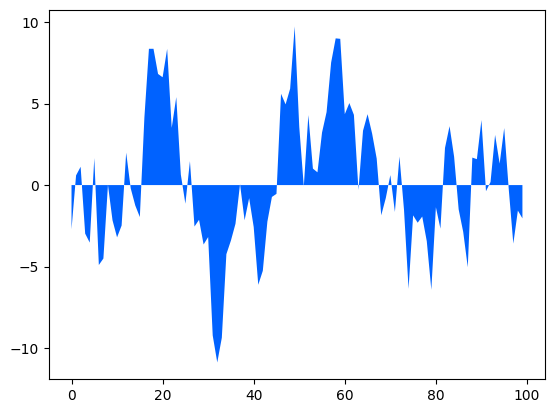

In [3]:
plt.fill_between(time,ar1_sample)


In [4]:
model = sm.tsa.ARIMA(ar1_sample, order=(1,0,0)).fit()
model.params

array([0.13538633, 0.73323115, 7.89468564])

In [ ]:
np.random.seed(112)
ar2_sample = np.zeros(100)
ar2_sample[0:2] += np.random.normal(loc=0, scale=2.5, size=2)
for t in time[2:]:
    ar2_sample[t] = (0.3 * ar2_sample[t-1]) + (0.3 * ar2_sample[t-2]) + np.random.normal(loc=0, scale=2.5, size=1)

C:\Users\jrdiy\AppData\Local\Temp\ipykernel_17220\4129647403.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ar2_sample[t] = (0.3 * ar2_sample[t-1]) + (0.3 * ar2_sample[t-2]) + np.random.normal(loc=0, scale=2.5, size=1)


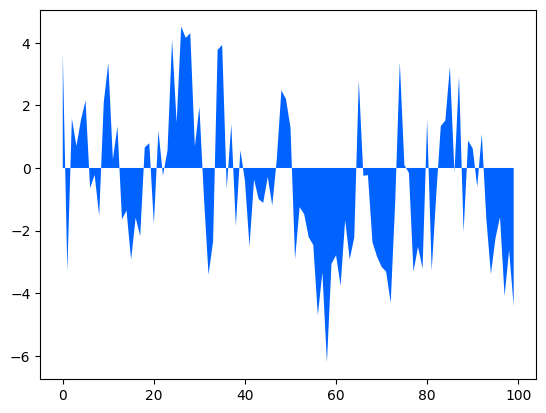

In [6]:
plt.fill_between(time, ar2_sample)

In [7]:
model = sm.tsa.ARIMA(ar2_sample,order=(2,0,0)).fit()
model.params

array([-0.53966327,  0.35251402,  0.23334235,  4.23778684])

In [8]:
from statsmodels.tsa.arima_process import arma_generate_sample

arparams = np.array([0.3,0.3])
maparams = np.array([0])
ar = np.r_[1, -arparams]
ma = np.r_[1, maparams]
y = arma_generate_sample(ar, ma, 100 )

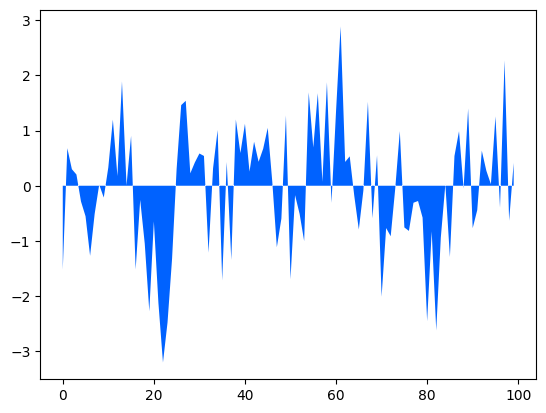

In [9]:
plt.fill_between(time, y)

In [10]:
model  = sm.tsa. ARIMA(y, order=(2,0,0)).fit()
model.params

array([-0.06184517,  0.17136503,  0.31734628,  1.08004523])

In [11]:
model.param_names

['const', 'ar.L1', 'ar.L2', 'sigma2']

In [12]:
list(zip(model.param_names, model.params))

[('const', np.float64(-0.061845166818615516)),
 ('ar.L1', np.float64(0.17136502772698592)),
 ('ar.L2', np.float64(0.3173462790302275)),
 ('sigma2', np.float64(1.0800452286226807))]

In [13]:
np.random.seed(12)

time = np.arange(100)

ma1_sample = np.zeros(100)

error = np.random.normal(loc=0, scale=2.5, size=100)

ma1_sample[0] +=error[0]

for t in time[1:]:
    ma1_sample[t] = (0.4 * error[t-1]) + error[t]
    

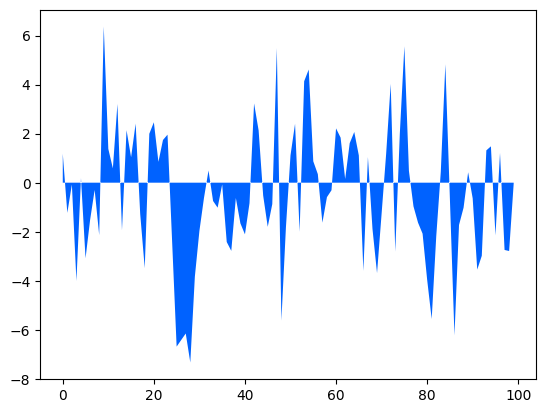

In [14]:
plt.fill_between(time, ma1_sample)

In [15]:
sm.tsa.ARIMA(ma1_sample, order=(0,0,1)).fit()
model.params

array([-0.06184517,  0.17136503,  0.31734628,  1.08004523])

In [16]:
model.param_names

['const', 'ar.L1', 'ar.L2', 'sigma2']

In [34]:
time = np.arange(100)

time = np.arange(100)
ma2_sample = np.zeros(100)
error = np.random.normal(loc=0, scale=2.5, size=100)
ma2_sample[0:2] = error[0:2]

for t in time[2:]:
    ma2_sample[t] = (0.4 * error[t-1]) + (-0.4 * error[t-2]) + error[t]
    

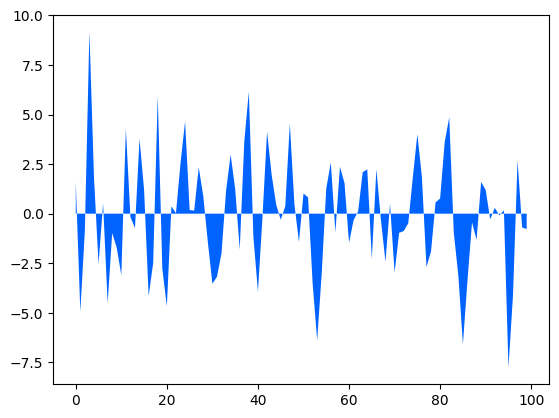

In [35]:
plt.fill_between(time, ma2_sample)

In [36]:
model = sm.tsa.ARIMA(ma2_sample, order=(0,0,2), trend='n').fit()
model.params

array([ 0.44129306, -0.40567209,  5.82163815])

In [37]:
np.random.seed(123)
arparams = np.array([0])
maparams = np.array([0.4, -0.4])
ar = np.r_[1, -arparams]
ma = np.r_[1, maparams]
y = arma_generate_sample(ar, ma, 100)


In [38]:
model = sm.tsa.ARIMA(y,  order=(0,0,2), trend='n').fit()
model.params

array([ 0.45955969, -0.41054723,  1.24968968])

In [39]:
model.param_names

['ma.L1', 'ma.L2', 'sigma2']

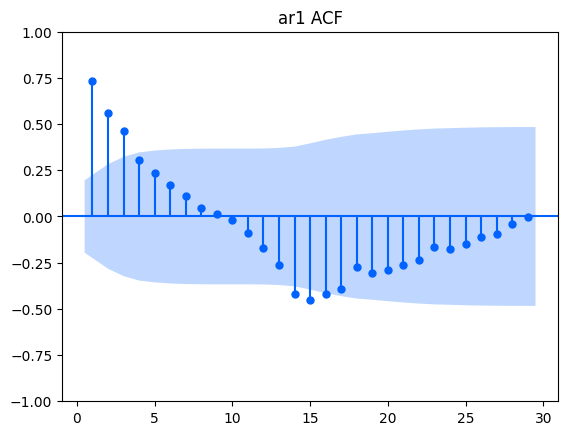

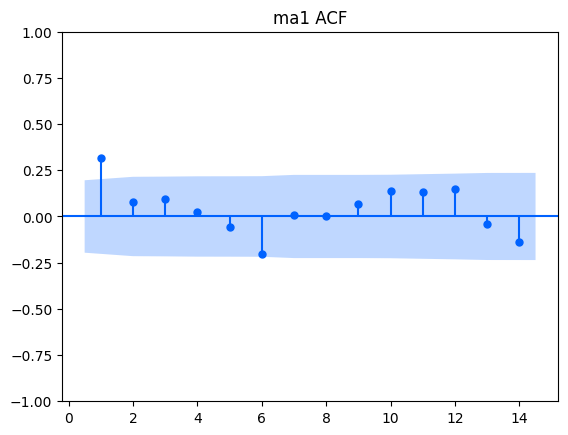

In [40]:
fig = sm.tsa.graphics.plot_acf(ar1_sample, lags=range(1,30), alpha=0.05, title='ar1 ACF')
fig = sm.tsa.graphics.plot_acf(ma1_sample, lags =range(1,15), alpha=0.05, title='ma1 ACF')


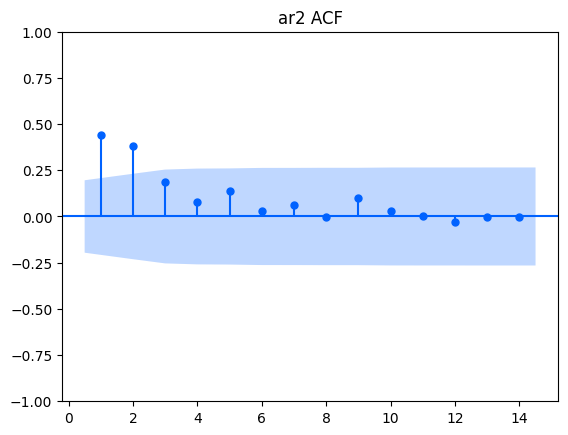

In [41]:
fig =  sm.tsa.graphics.plot_acf(ar2_sample, lags=range(1,15), alpha=0.05, title = 'ar2 ACF')


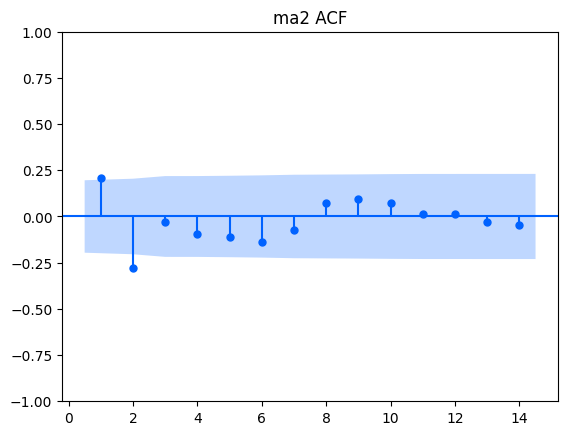

In [42]:
fig = sm.tsa.graphics.plot_acf(ma2_sample, lags=range(1,15), alpha=0.05,title = 'ma2 ACF')

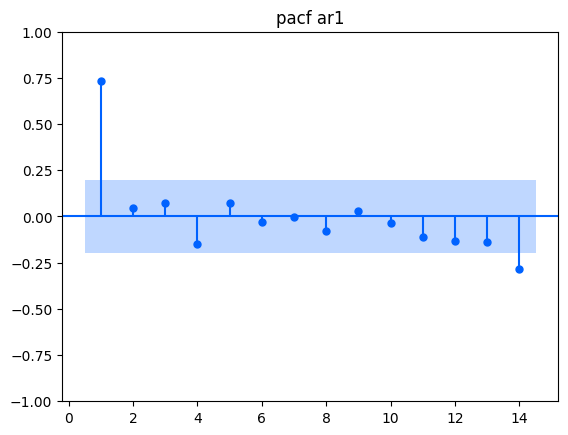

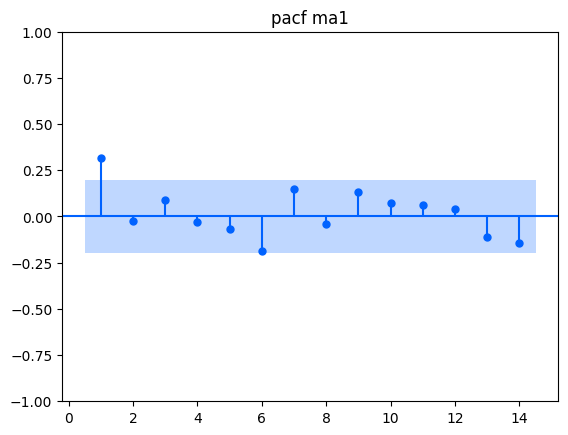

In [43]:
from statsmodels.graphics.tsaplots import plot_pacf

fig = sm.tsa.graphics.plot_pacf(ar1_sample, lags=range(1,15), alpha=0.05, title = 'pacf ar1')
fig = sm.tsa.graphics.plot_pacf(ma1_sample, lags=range(1,15), alpha=0.05, title = 'pacf ma1')

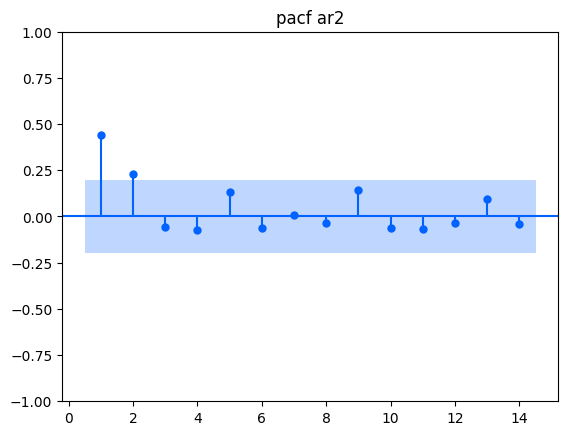

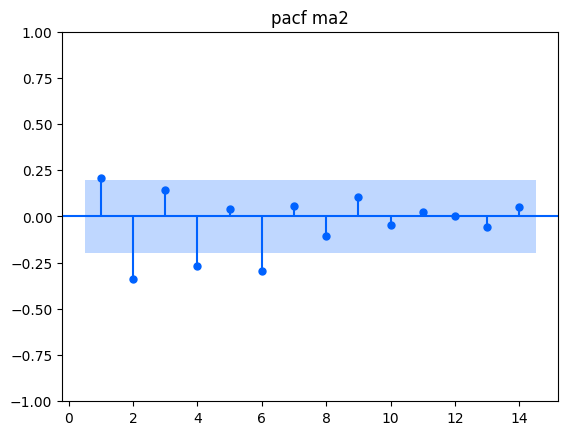

In [44]:
fig = sm.tsa.graphics.plot_pacf(ar2_sample, lags=range(1,15), alpha=0.05, title = 'pacf ar2')
fig = sm.tsa.graphics.plot_pacf(ma2_sample, lags=range(1,15), alpha=0.05, title = 'pacf ma2')

In [46]:
path_to_file = r"C:\Users\jrdiy\OneDrive\Рабочий стол\vs_code\Time-series\ARMA\\"
auto_1 = pd.read_csv(path_to_file + "auto_1.csv")
auto_2 = pd.read_csv(path_to_file + "auto_2.csv")

In [48]:
mytime = np.arange(len(auto_1))


In [49]:
auto_1.values.shape

(100, 1)

In [50]:
auto_1 = auto_1.values.reshape(-1)
auto_2 = auto_2.values.reshape(-1)

In [52]:
auto_1.shape

(100,)

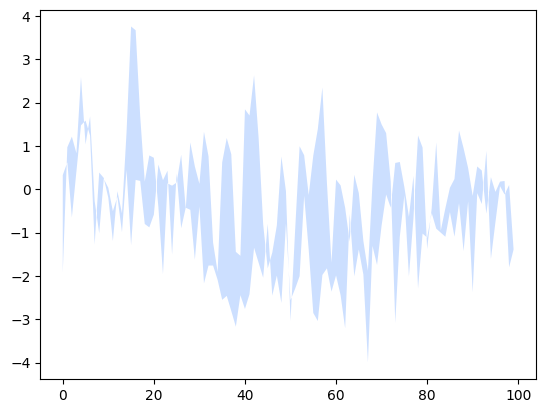

In [ ]:
plt.fill_between(mytime, auto_1, auto_2, alpha =0.2)

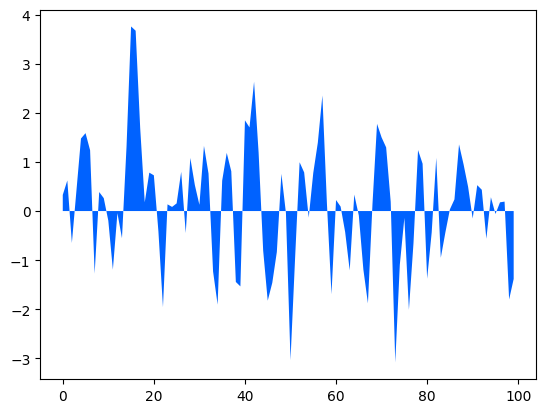

In [54]:
plt.fill_between(mytime, auto_2)

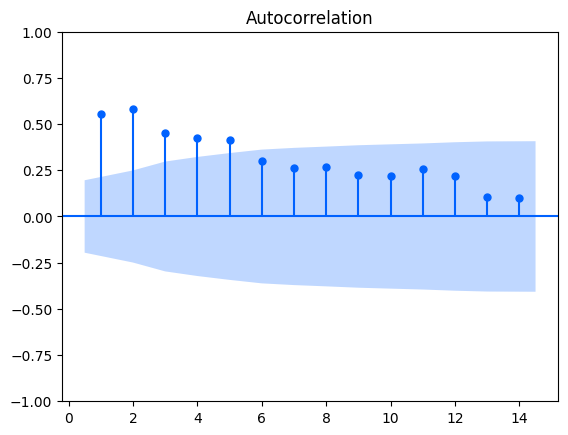

In [55]:
fig1  = sm.tsa.graphics.plot_acf(auto_1, lags = range(1,15),alpha=0.05)

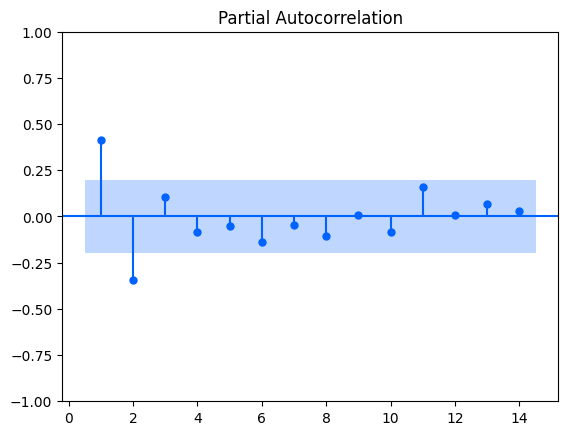

In [56]:
fig2 = sm.tsa.graphics.plot_pacf(auto_2, lags=range(1,15), alpha=0.05)


In [60]:
model = sm.tsa.ARIMA(auto_1, order=(2,0,0), trend='n').fit()
print(model.params)

[0.37346212 0.48047418 0.89016204]


In [63]:
model.param_names

['ar.L1', 'ar.L2', 'sigma2']

In [65]:
model = sm.tsa.ARIMA(auto_2, order=(0,0,1),trend='n').fit()
model.params

array([0.62846392, 1.1174902 ])